<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import cv2 as cv
from typing import List

In [ ]:
# helper function to read images
def readImages(filepaths: List[np.ndarray], mode: str) -> List[np.ndarray]:
    images = []
    validModes = ["color", 'gray']

    if not(mode in validModes): return f"Not valid mode: {mode}, validModes are: {validModes}"

    if mode == "color":
      for filepath in filepaths:
        try:
          image = cv.imread(filepath)
          image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
          images.append(image)

        except FileNotFoundError:
          ValueError(f"File path not found: {filepath}")
        except Exception as e:
          ValueError(f"Unknown error occured: {e}")

      return images
    elif mode == "gray":
      for filepath in filepaths:
        try:
          image = cv.imread(filepath, 0)
          images.append(image)

        except FileNotFoundError:
          ValueError(f"File path not found: {filepath}")
        except Exception as e:
          ValueError(f"Unknown error occured: {e}")

      return images

In [ ]:
# emee filter function
def filter(Imax: float, Imin: float, alpha: float, c: float) -> float:
  Imax = float(Imax)
  Imin = float(Imin)
  c = float(c)
  denominator = np.maximum(Imin + c, 1e-12)
  r = Imax / (denominator)
  # # avoids log(0)
  r = max(r, 1e-12)
  return alpha * (r) ** alpha * np.log(r)

def divideBlock(image: np.ndarray, k1: int, k2: int) -> List[np.ndarray]:
  if image is None:
    print(f"Not valid image")
    return

  height, width = image.shape

  blockHeight = height // k1
  blockWidth = width // k2

  blocks = []

  for i in range(k1):
    for j in range(k2):
      block = image[i * blockHeight: (i + 1) * blockHeight, j * blockWidth: (j + 1) * blockWidth]
      blocks.append(block)

  return blocks

def EMEE(image: np.ndarray, alpha: float, k1: int, k2: int, c: float) -> float:
  quality = 0
  blocks = divideBlock(image, k1, k2)

  blockSize = k1 * k2

  # This version uses too many loops
  # for i in range(blockSize):
  #   Imax = math.float('-inf')
  #   Imin = math.float('inf')

  #   for h in range(len(blocks[i])):
  #     for j in range(len(blocks[i][h])):
  #       Imax = max(Imax, blocks[i][h][j])
  #       Imin = min(Imin, blocks[i][h][j])

  #   quality += filter(Imax, Imin, alpha, c)

  for block in blocks:
    Imax = np.max(block)
    Imin = np.min(block)
    quality += filter(Imax, Imin, alpha, c)

  return (1 / blockSize) * quality

alpha = 0.9
k1, k2 = 8, 8
c = 1

In [ ]:
# gray images
commonPath = '/content'
grayFilePaths = [
    f'{commonPath}/distored_apple.png',
    f'{commonPath}/original_apple.png',
    f'{commonPath}/food_3.jpg',
    f'{commonPath}/distoredBurger.png',
    f'{commonPath}/equalize.png'
]

grayImages = readImages(grayFilePaths, "gray")

distoredApple = grayImages[0]
regularApple = grayImages[1]
burgerGray = grayImages[2]
distoredBurger = grayImages[3]

dog = grayImages[4]

In [ ]:
# colored images
coloredFilePaths = [
     f'{commonPath}/food_1.JPG',
     #f'{commonPath}/mountain.jpg',
     f'{commonPath}/darkMountain.png'
]

colorImages = readImages(coloredFilePaths, 'color')
steak = colorImages[0]
darkMountain = colorImages[1]

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
  try:
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
  except Exception as e:
    return ValueError(f"Unknown error occured: {e}")

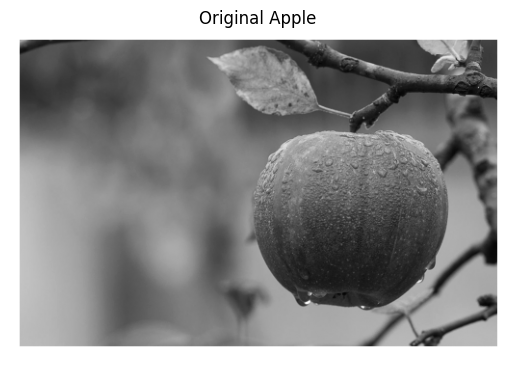

In [ ]:
show(regularApple, cmap="gray", title="Original Apple")

In [ ]:
EMEE(regularApple, alpha, k1, k2, c)

np.float64(6.696510404335534)

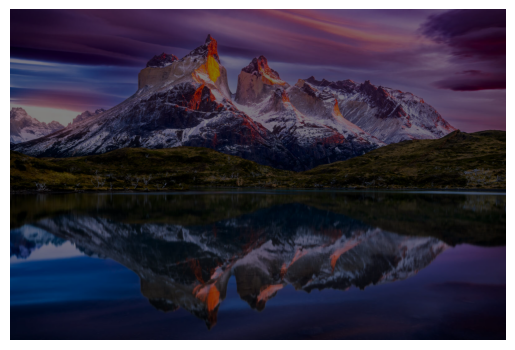

In [ ]:
show(darkMountain)

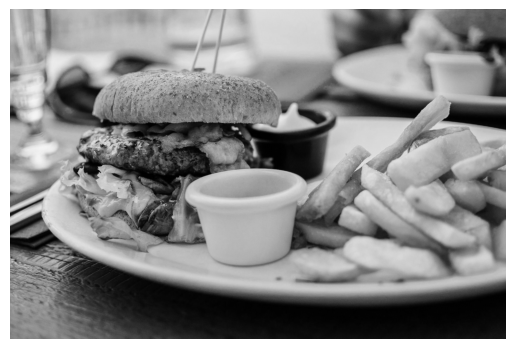

In [ ]:
show(burgerGray, cmap="gray")

In [ ]:
EMEE(distoredApple, alpha, k1, k2, c)

np.float64(0.04441324712999236)

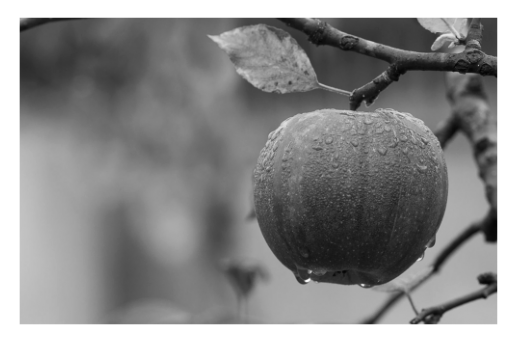

In [ ]:
show(regularApple, cmap="gray")

In [ ]:
# source: https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html
def plotHistogram(image: np.ndarray, bins: int = 256):
  hist, bins = np.histogram(image.flatten(), 256, [0,256])

  cdf = hist.cumsum()
  cdf_normalized = cdf * float(hist.max()) / cdf.max()

  plt.plot(cdf_normalized, color = 'b')
  plt.hist(image.flatten(), 256, color = 'r')
  plt.xlim([0,256])
  plt.legend(('cdf', 'histogram'), loc = 'upper left')
  plt.show()

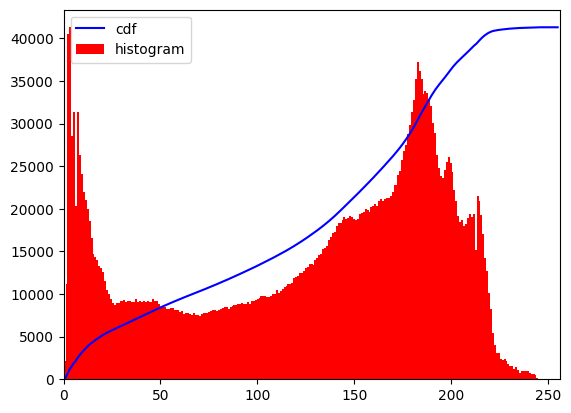

In [ ]:
plotHistogram(burgerGray)

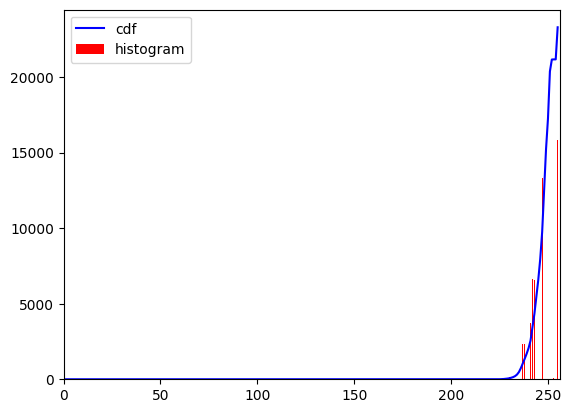

In [ ]:
plotHistogram(distoredApple)

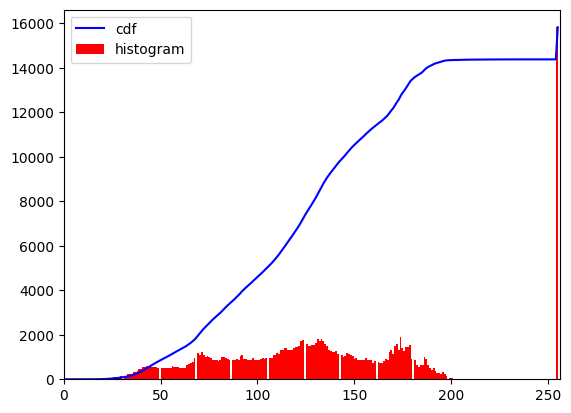

In [ ]:
plotHistogram(regularApple)

/tmp/ipython-input-4012995323.py:2: RuntimeWarning: overflow encountered in exp
  return 255.0 / (1 + np.exp(-a * (x - 127.0) / 32.0))


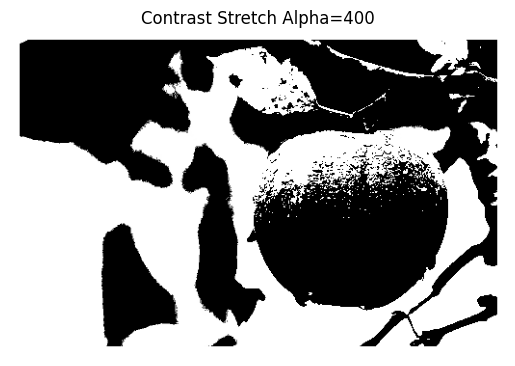

In [ ]:
def constrastFormula(a: float, x: float) -> float:
  return 255.0 / (1 + np.exp(-a * (x - 127.0) / 32.0))

def contrastStretch(image: np.ndarray, a: float) -> np.ndarray:
    x = image.astype(np.float32)

    new_image = constrastFormula(a, x)

    return np.clip(new_image, 0, 255).astype(np.uint8)

constrast_img = contrastStretch(regularApple, a=400)
show(constrast_img, cmap="gray", title="Contrast Stretch Alpha=400")

In [ ]:
EMEE(regularApple, alpha, k1, k2, c)

np.float64(6.696510404335534)

In [ ]:
EMEE(constrast_img, alpha, k1, k2, c)

np.float64(627.9606501351462)

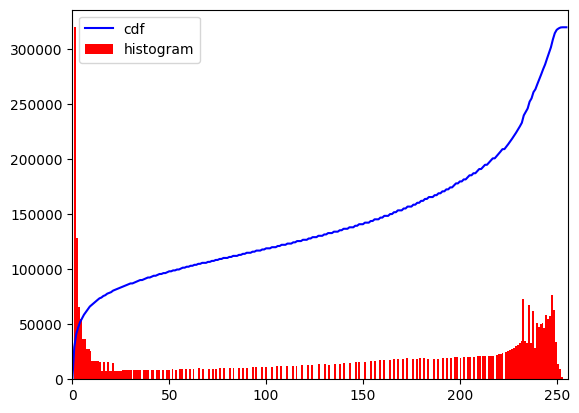

In [ ]:
plotHistogram(constrast_img)

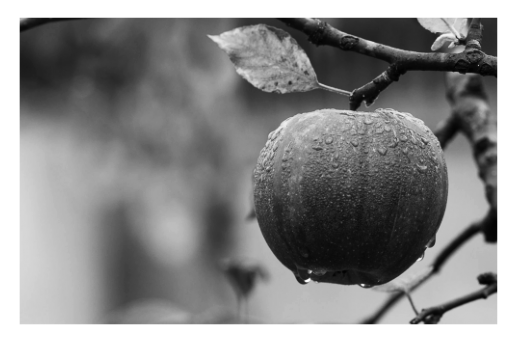

In [ ]:
# helper function to find average of a histogram
def averageHist(image: np.ndarray) -> float:
  return float(np.mean(image))

def newContrastFormula(image: np.ndarray, a: float, x: float, b: float) -> float:
  # 255 / (1 + e^(-a * (x - average) / b))
  return 255.0 / (1 + np.exp(-a * (x - averageHist(image)) / b))

def newContrastStretch(image: np.ndarray, a: float, b: float) -> np.ndarray:
  x = image.astype(np.float32)

  new_image = newContrastFormula(image, a, x, b)

  return np.clip(new_image, 0, 255).astype(np.uint8)

newContrastImg = newContrastStretch(regularApple, a=1.4, b=67)
show(newContrastImg, cmap="gray")

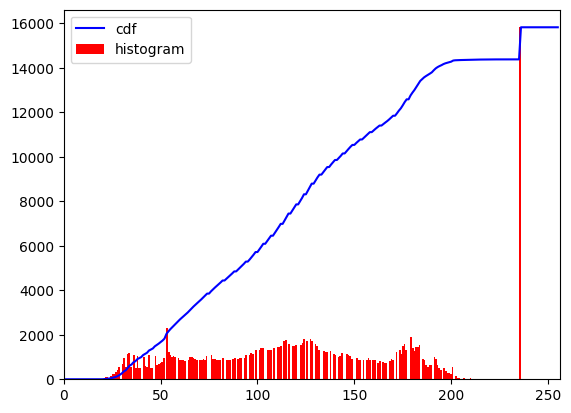

In [ ]:
plotHistogram(newContrastImg)

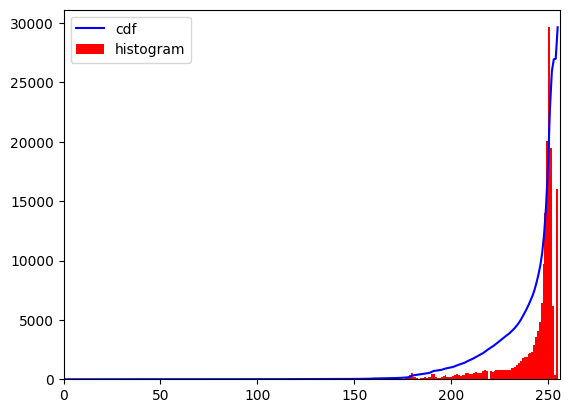

In [ ]:
plotHistogram(distoredBurger)

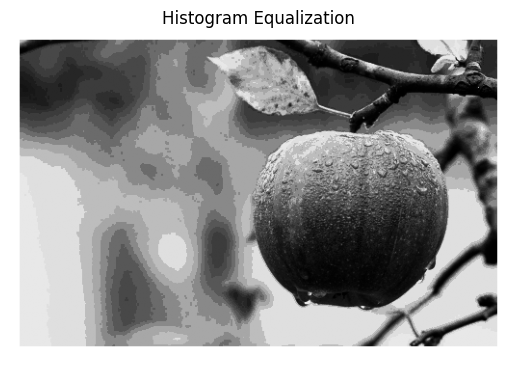

In [ ]:
def equalize(image: np.ndarray) -> np.ndarray:
  # for part 5 of hw to equalize v component
  histogram = np.zeros(256)
  height, width = image.shape

  for h in range(height):
    for w in range(width):
      imgIntensity = image[h, w]
      histogram[imgIntensity] += 1

  # compute pdf
  totalPixels = height * width

  pdf = (histogram / totalPixels)

  # compute cdf
  cdf = np.zeros(256)
  cdf[0] = pdf[0]

  for i in range(1, 256):
    cdf[i] = cdf[i - 1] + pdf[i]

  # transform image by multiplying by 255
  transform = np.round(255 * cdf).astype(np.uint8)

  equalized = np.zeros_like(image)

  for h in range(height):
    for w in range(width):
      equalized[h, w] = transform[image[h, w]]

  return equalized

equImg = equalize(distoredApple)
show(equImg, cmap="gray", title="Histogram Equalization")

In [ ]:
EMEE(equImg, alpha, k1, k2, c)

np.float64(22.765510239285497)

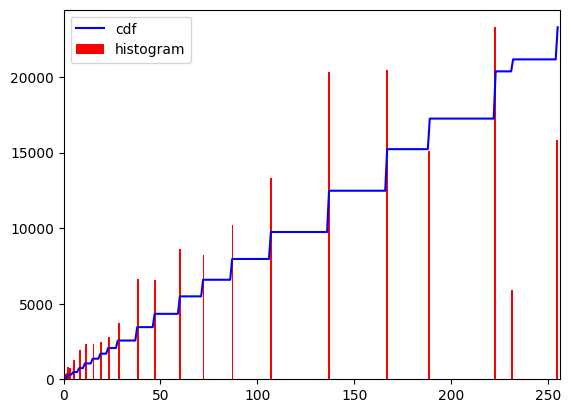

In [ ]:
plotHistogram(equImg)

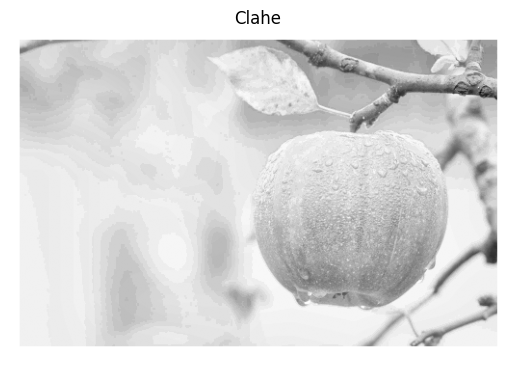

In [ ]:
def claheEqualize(image: np.ndarray) -> np.ndarray:
    clipLimit = 3.0
    tileGridSize = (8, 8)

    clahe = cv.createCLAHE(
        clipLimit=clipLimit,
        tileGridSize=tileGridSize
    )

    # # for color enhancement (part 5 of hw)
    # if image.ndim == 2:
    #     return clahe.apply(image.astype(np.uint8))

    eq = clahe.apply(image)

    return eq

clahe = claheEqualize(distoredApple)
show(clahe, cmap="gray", title="Clahe")

In [ ]:
EMEE(clahe, alpha, k1, k2, c)

np.float64(0.14371142312042387)

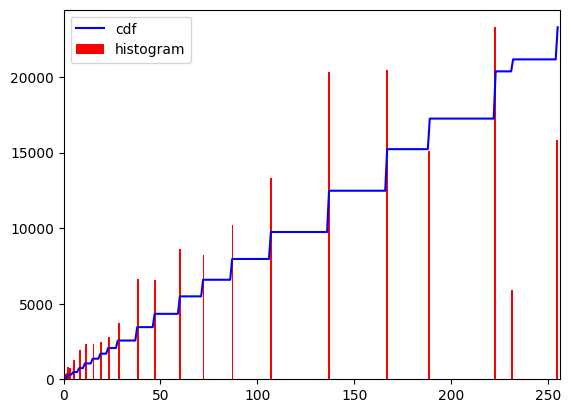

In [ ]:
plotHistogram(equImg)

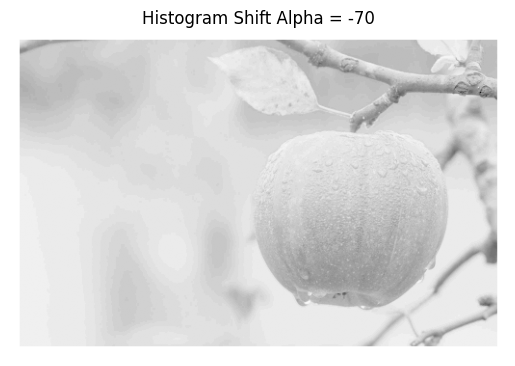

In [ ]:
def histogramShift(image: np.ndarray, alpha: int) -> np.ndarray:
    """
    Shift grayscale histogram by alpha.
    delta > 0  -> brighter
    delta < 0  -> darker
    """
    x = image.astype(np.int16)
    y = x + alpha
    return np.clip(y, 0, 255).astype(np.uint8)

shiftedHistogramImg = histogramShift(image=distoredApple, alpha=-70)
show(shiftedHistogramImg, cmap="gray", title="Histogram Shift Alpha = -70")

In [ ]:
EMEE(shiftedHistogramImg, alpha, k1, k2, c)

np.float64(0.012037745401500512)

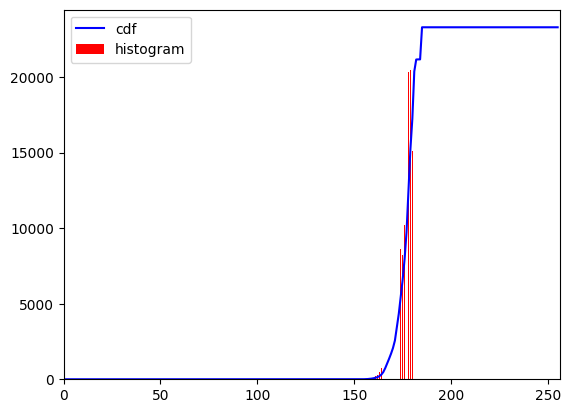

In [ ]:
plotHistogram(shiftedHistogramImg)

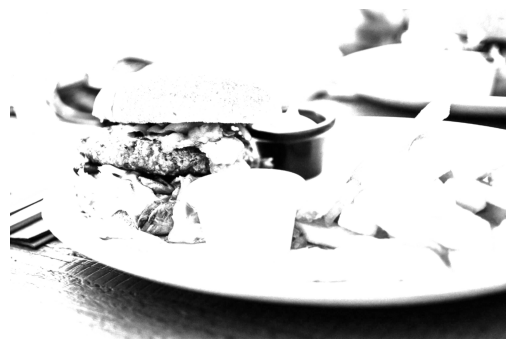

In [ ]:
def gammaFormula(c: float, z: float, a: float, upsilon: float) -> float:
  return c * np.pow((z + a), upsilon)

def gammaCorrection(image: np.ndarray, c: float = 1.2, a: float = 0.0, upsilon: float = 1.0) -> np.ndarray:
  """
  Source: Sos Agaian CSC 475 Slideshow 2 Slide 41

  γ < 1: Expands values of dark pixels compress values of brighter
  pixels
  For γ > 1: Compresses values of dark pixels, expand values of brighter pixels
  If γ=1 & c=1: Identity transformation (s = r)
  """

  z = image.astype(np.float32)

  correctedImage = gammaFormula(c, z, a, upsilon)

  return np.clip(correctedImage, 0, 255).astype(np.uint8)


gammaCorrected = gammaCorrection(burgerGray, c=2.0, a=1.0, upsilon=1.1)
show(gammaCorrected, cmap="gray")

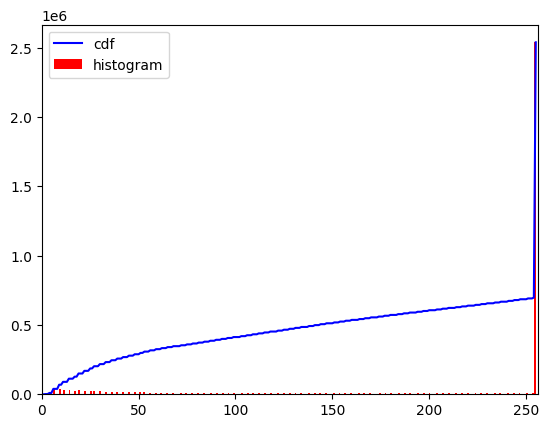

In [ ]:
plotHistogram(gammaCorrected)

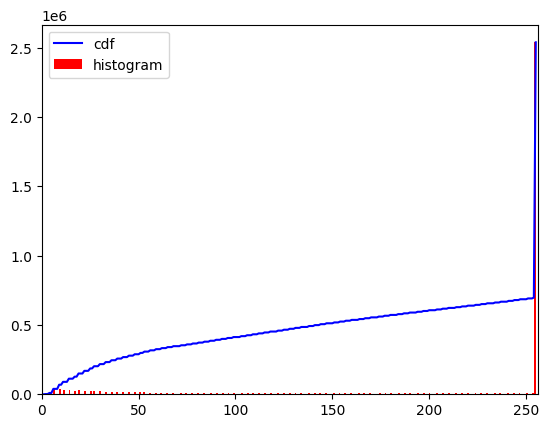

In [ ]:
plotHistogram(gammaCorrected)

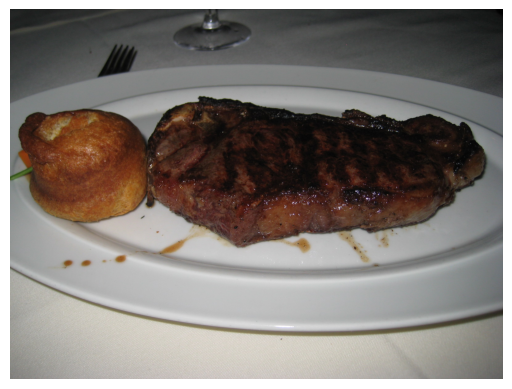

In [ ]:
show(steak)

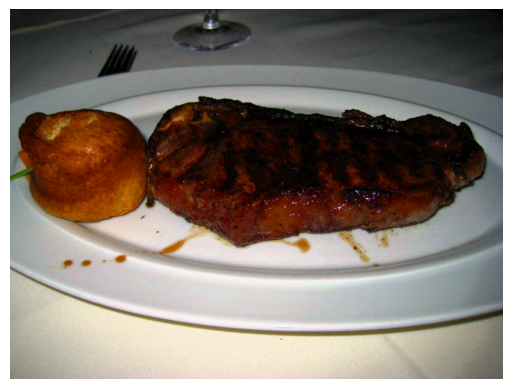

In [ ]:
# Steps taken from Sos Agaian Slideshow 2
def colorEnhance(image_1: np.ndarray, enhanceFunc: str) -> np.ndarray:
  validEnhanceFuncs = ["gammaCorrection", "histogramShift", "equalize", "clahe"]

  if not(enhanceFunc in validEnhanceFuncs):
    raise ValueError(f"Not a valid enhancement function: valid functions are: {validEnhanceFuncs}")

  # step 1: convert rgb to hsv
  hsv_image = cv.cvtColor(image_1, cv.COLOR_RGB2HSV)

  # step 2: apply an image enhancement function on component v
  oldV = hsv_image[:, :, 2]
  newV = oldV.copy()

  # function implementations
  if enhanceFunc == "gammaCorrection":
    c = 1.4
    a = 1.3
    upsilion = 1.001

    newV = gammaFormula(c, newV, a, upsilion)
  elif enhanceFunc == "histogramShift":
    shift = 25

    newV = histogramShift(newV, shift)
  elif enhanceFunc == "equalize":
    newV = equalize(newV)
  elif enhanceFunc == "clahe":
    newV = claheEqualize(newV)

  newV = np.clip(newV, 0, 255)
  hsv_image[:, :, 2] = newV

  # step 3: apply median filtering and linear enhancement on saturation component s
  s = hsv_image[:, :, 1]

  # median filter on s
  sMedianFilter = cv.medianBlur(s, 3)

  # linear enhancement on s
  a = 1.5
  b = 10

  # a * sMedianFilter + b for linear enhancement
  sPrime = a * sMedianFilter + b
  sPrime = np.clip(sPrime, 0, 255)

  hsv_image[:, :, 1] = sPrime

  # Step 4: convert rgb to hsv
  rgb_image = cv.cvtColor(hsv_image, cv.COLOR_HSV2RGB)

  # Step 5: apply color correction
  oldRed = rgb_image[:, :, 0]
  oldBlue = rgb_image[:, :, 1]
  oldGreen = rgb_image[:, :, 2]

  # no divide by 0
  oldV = np.maximum(oldV, 1.0)

  rgb_image[:, :, 0] = ((oldRed / oldV) * newV)
  rgb_image[:, :, 1] = ((oldBlue / oldV) * newV)
  rgb_image[:, :, 2] = ((oldGreen / oldV) * newV)

  return rgb_image


#show(colorEnhance(darkMountain, "gammaCorrection"))
gammaCorrected = colorEnhance(steak, "histogramShift")
histEqualize = colorEnhance(steak, "equalize")
show(histEqualize)